## <u>K Means Algorithm</u>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

## 1. Creating the Data Set

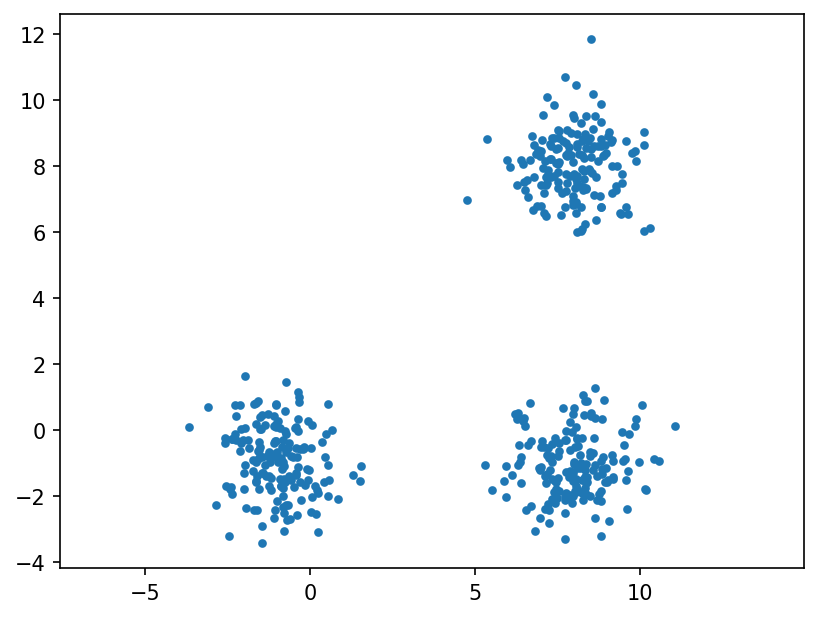

In [2]:
plt.rcParams['figure.dpi'] = 150 

# 500 data points 
N = 500 

np.random.seed(42)

center1  = np.random.randn(N//3 , 2) + np.array([8, 8])
center2 = np.random.randn(N//3 , 2) + np.array([8, -1])
center3 = np.random.randn(N//3 , 2) + np.array([-1, -1])


X = np.concatenate((center1, center2, center3))
plt.scatter(X[:, 0], X[:, 1], s = 10)
plt.axis("equal")
plt.show()

In [3]:
print(X[:5, :])
print(X.shape)

[[8.49671415 7.8617357 ]
 [8.64768854 9.52302986]
 [7.76584663 7.76586304]
 [9.57921282 8.76743473]
 [7.53052561 8.54256004]]
(498, 2)


### Defining the Objective Function 

In [4]:
def objectiveFunction(X, clusterCenters): 
    return sum(
        [np.min(
            [np.linalg.norm(x_i - cluster_center)**2 for cluster_center in clusterCenters]
        ) for x_i in X]
    )

### Algorithm Strategy: 

<ul>
    <li> <b>Initialization Step: </b>Assign random data points from the data set as the cluster centers
    <li> <b>Cluster Assignment Step: </b> For every data point, assign a cluster indicator as per the least distance from the cluster means 
    <li> <b>Recompute Cluster Centers: </b> For every cluster indicator recompute the cluster mean
    <li> Repeat steps 2 and 3 until convergence
</ul>

### Initialization Step 

In [10]:
K = 3 # three clusters 

clusterCenters = X[np.random.choice(len(X), 3)]
#clusterCenters = X[[70, 85, 80]] # this picks 3 rows 
print(clusterCenters)

[[ 8.50498728  8.86575519]
 [-2.00162001 -1.28110029]
 [10.13303337  6.0479122 ]]


### Cluster Assignment Step 

For every datapoint, the cluster indicator whose center is closest to the datapoint is assigned as its cluster.

(np.float64(-13.724036325918028),
 np.float64(25.808133611717242),
 np.float64(-16.71024605359066),
 np.float64(17.94994343763669))

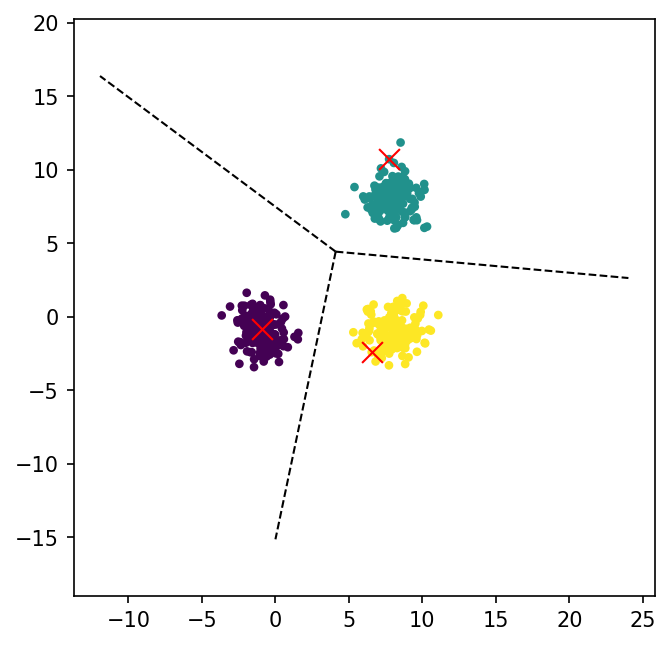

In [6]:
from scipy.spatial import Voronoi, voronoi_plot_2d 


def clusterAssignment(X, clusterCenters): 
    Z = np.zeros(X.shape[0]) # 498 data points
    Z = [np.argmin([np.linalg.norm(X[i] - cluster_center) for cluster_center in clusterCenters])for i in range(len(Z))]
    return Z 

z = clusterAssignment(X, clusterCenters=clusterCenters)

# plotting the voronoi regions 
fig, (ax) = plt.subplots(1, 1)
fig.set_size_inches(5 , 5)

ax.scatter(X[:, 0], X[:, 1], c=z, s=10)
ax.scatter(clusterCenters[:,0], clusterCenters[:,1], marker="x", s=100, color="red", linewidth=1)

vor = Voronoi(clusterCenters)
voronoi_plot_2d(vor, ax=ax, show_points = False, show_vertices=False)

ax.axis("equal")

### Recomputing the Means/Cluster Centers

In [7]:
def recompute_clusters(X, z):
    cluster_centers = np.array(
        [np.mean(X[z == i], axis=0) for i in range(X.shape[0])]
    )
    return cluster_centers

### Iteration of K-means

<li>Assign clusters based on new cluster centers.</li>
<li>Recompute cluster centers based on new clusters.</li>


ValueError: Input points array must have 2 dimensions.

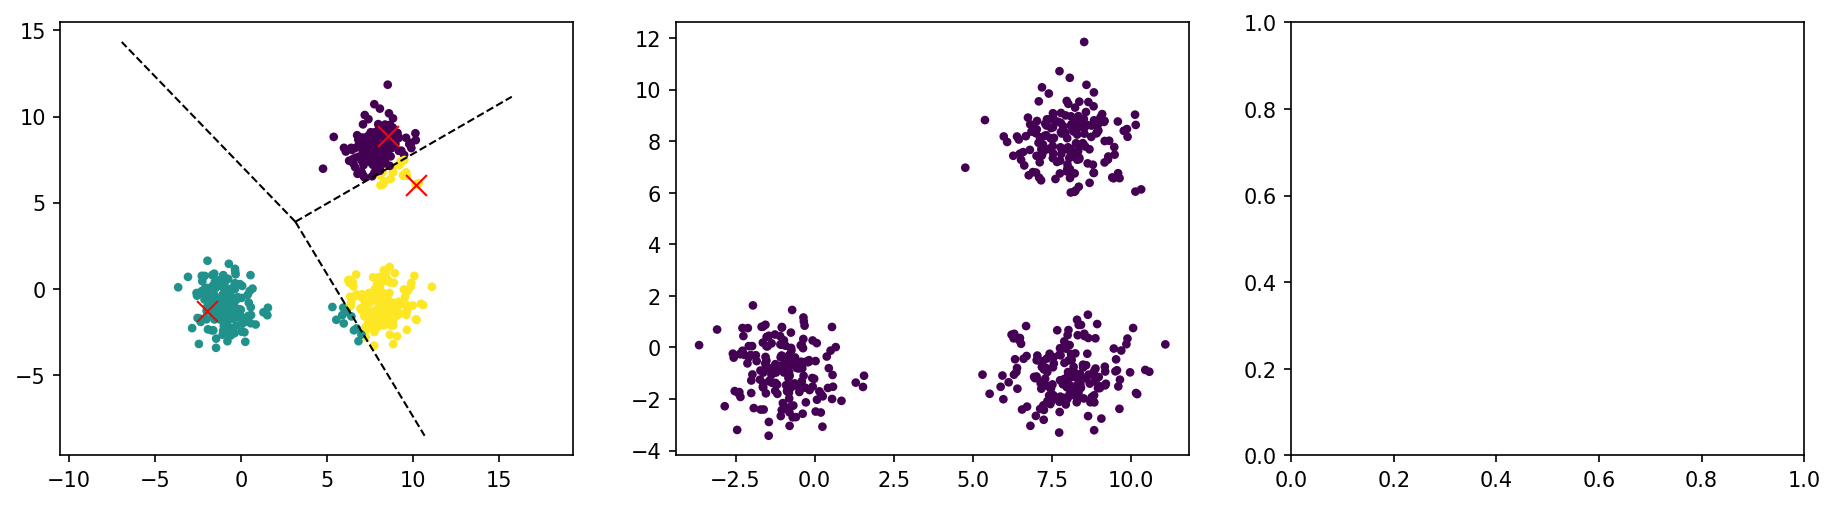

In [11]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 3.75)

for i in range(3):

  z = clusterAssignment(X, clusterCenters) # cluster_centers -> NEW cluster assignment ->

  ax[i].scatter(X[:, 0], X[:, 1], c=z, s=10)
  ax[i].scatter(clusterCenters[:, 0], clusterCenters[:, 1], marker = 'x', s = 100, color = 'red', linewidth=1)
  vor = Voronoi(clusterCenters)
  voronoi_plot_2d(vor, ax=ax[i], show_points=False, show_vertices=False)
  ax[i].axis('equal')

  clusterCenters = recompute_clusters(X, z) # -> cluster assignment -> NEW cluster centers